In [1]:
import os
import pandas as pd
import numpy as np
import pefile
from tqdm import tqdm

In [2]:
MALWARE_DIR = "../malware_samples"

files = os.listdir(MALWARE_DIR)
len(files)

40

In [3]:
files[:10]

['JH78C0A33A1B472A8C16123FD696A5CE5EBB',
 'AAAz2E1B6940985A23E5639450F8391820655',
 '650A6FCA433EE243391E4B4C11F09438',
 'JKK8CA6FE7A1315AF5AFEAC2961460A80569',
 'VBMM9_149B7BD7218AAB4E257D28469FDDB0D',
 'SAM_B659D71AE168E774FAAF38DB30F4A84',
 'KLp90_6D5C8FC4B14559F73B6136D85B94198',
 'B98hX8E8622C393D7E832D39E620EAD5D3B49',
 'F8437E44748D2C3FCF84019766F4E6DC',
 'F6655E39465C2FF5B016980D918EA028']

In [4]:
# Creación de función que extrae features

def extract_features(filepath):
    
    features = {}
    
    try:
        pe = pefile.PE(filepath)
        
        # número de secciones
        features["num_sections"] = len(pe.sections)
        
        # tamaño del archivo
        features["file_size"] = os.path.getsize(filepath)
        
        # número de imports
        num_imports = 0
        
        if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                num_imports += len(entry.imports)
        
        features["num_imports"] = num_imports
        
    except:
        # si no se puede analizar PE
        features["num_sections"] = 0
        features["file_size"] = 0
        features["num_imports"] = 0
    
    return features

In [5]:
# Construir el dataset

data = []

for f in tqdm(files):
    
    path = os.path.join(MALWARE_DIR, f)
    
    features = extract_features(path)
    
    features["sample"] = f
    
    data.append(features)

df = pd.DataFrame(data)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 351.05it/s]


In [6]:
# Ver el dataset

df.head()

,num_sections,file_size,num_imports,sample
0,3,5632,8,JH78C0A33A1B472A8C16123FD696A5CE5EBB
1,3,344576,10,AAAz2E1B6940985A23E5639450F8391820655
2,3,5632,8,650A6FCA433EE243391E4B4C11F09438
3,3,5632,8,JKK8CA6FE7A1315AF5AFEAC2961460A80569
4,3,14336,8,VBMM9_149B7BD7218AAB4E257D28469FDDB0D


In [7]:
# Guardar el dataset

df.to_csv("../dataset/malware_dataset.csv", index=False)

In [8]:
# Extracción de strings

import subprocess

def extract_strings(filepath):
    
    try:
        result = subprocess.check_output(["strings", filepath])
        strings = result.decode("utf-8", errors="ignore")
        return strings
        
    except:
        return ""

In [9]:
# Extracción de funciones importadas

def extract_functions(filepath):
    
    functions = []
    
    try:
        pe = pefile.PE(filepath)
        
        if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                for imp in entry.imports:
                    if imp.name:
                        functions.append(imp.name.decode())
    
    except:
        pass
    
    return " ".join(functions)

In [10]:
# Reconstruir el dataset completo

data = []

for f in tqdm(files):

    path = os.path.join(MALWARE_DIR, f)

    features = extract_features(path)

    features["sample"] = f
    features["strings"] = extract_strings(path)
    features["functions"] = extract_functions(path)

    data.append(features)

df = pd.DataFrame(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 80.20it/s]


In [11]:
# Guardar el dataset final

df.to_csv("../dataset/malware_dataset.csv", index=False)

In [17]:
df.head()
df.columns
df[["sample", "num_sections", "num_imports", "file_size"]].head()

,sample,num_sections,num_imports,file_size
0,JH78C0A33A1B472A8C16123FD696A5CE5EBB,3,8,5632
1,AAAz2E1B6940985A23E5639450F8391820655,3,10,344576
2,650A6FCA433EE243391E4B4C11F09438,3,8,5632
3,JKK8CA6FE7A1315AF5AFEAC2961460A80569,3,8,5632
4,VBMM9_149B7BD7218AAB4E257D28469FDDB0D,3,8,14336


In [18]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    
    # dejar solo letras, números y espacios
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    
    # colapsar espacios múltiples
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [19]:
df["strings_clean"] = df["strings"].apply(clean_text)
df["functions_clean"] = df["functions"].apply(clean_text)

In [20]:
df["text_features"] = df["strings_clean"] + " " + df["functions_clean"]

In [21]:
df[["sample", "text_features"]].head(3)

,sample,text_features
0,JH78C0A33A1B472A8C16123FD696A5CE5EBB,this program cannot be run in dos mode richo u...
1,AAAz2E1B6940985A23E5639450F8391820655,this program cannot be run in dos mode rich up...
2,650A6FCA433EE243391E4B4C11F09438,this program cannot be run in dos mode richo u...


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_text = vectorizer.fit_transform(df["text_features"])

In [23]:
X_text.shape

(40, 5000)

In [24]:
from sklearn.preprocessing import StandardScaler
import numpy as np

numeric_features = df[["num_sections", "num_imports", "file_size"]].copy()

scaler = StandardScaler()
X_num = scaler.fit_transform(numeric_features)

In [25]:
from scipy.sparse import hstack

X = hstack([X_text, X_num])
X.shape

(40, 5003)

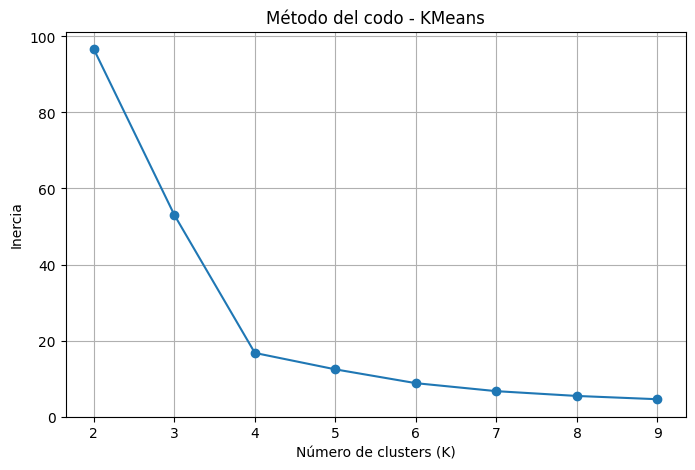

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo - KMeans")
plt.grid(True)
plt.show()

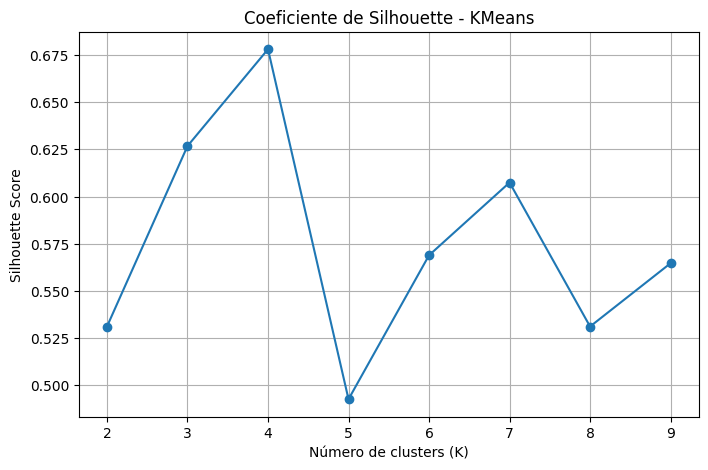

In [27]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Coeficiente de Silhouette - KMeans")
plt.grid(True)
plt.show()

In [28]:
list(zip(k_values, silhouette_scores))

[(2, 0.5309715656824736),
 (3, 0.6267608113430232),
 (4, 0.6781468514742468),
 (5, 0.49244042035547386),
 (6, 0.5688184782391144),
 (7, 0.6074074913421287),
 (8, 0.5310148667163295),
 (9, 0.564605329390536)]